## EDA: Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

In [ ]:
# Load CSV 

df = pd.read_csv("../data/merged_data.csv") #df = pd.read_csv("/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/merged_streaming_data.csv")

In [4]:
vle_columns = ['quiz', 'questionnaire', 'externalquiz', 'oucontent', 'page', 
              'resource', 'url', 'homepage', 'glossary', 'subpage', 'folder', 
               'forumng', 'oucollaborate', 'ouelluminate', 'ouwiki', 'sharedsubpage', 
               'dataplus','repeatactivity', 'dualpane', 'htmlactivity']
course_student_vle_cols = ['code_module','code_presentation','module_presentation_length', 'date', 
                           'id_student','final_result','date_registration','date_unregistration'
                          ] + vle_columns

# Keep columns relevant to vle interactions and drop duplicate rows that arose if students submitted multiple assessments on a given date
df = df[course_student_vle_cols].drop_duplicates()
# Keep rows where at least one VLE column is nonzero and not NaN
df = df[df[vle_columns].fillna(0).sum(axis=1) > 0] # takes care of instances where there is NaN in a column (I noticed it in quiz) and everything else is 0

In [5]:
# Check for missing values / zeros 

summary = pd.DataFrame({
    'Zero Count': (df == 0).sum(),
    'Non-Zero Count': (df != 0).sum(),
    'Total Non-Null': df.count()
})
summary['% Zero'] = (summary['Zero Count'] / summary['Total Non-Null'] * 100).round(2)
summary['% Non-Zero'] = (summary['Non-Zero Count'] / summary['Total Non-Null'] * 100).round(2)
print(summary)

                            Zero Count  Non-Zero Count  Total Non-Null  \
code_module                          0         1808119         1808119   
code_presentation                    0         1808119         1808119   
module_presentation_length           0         1808119         1808119   
date                              9451         1798668         1808119   
id_student                           0         1808119         1808119   
final_result                         0         1808119         1808119   
date_registration                  172         1807947         1808020   
date_unregistration               1119         1807000          164683   
quiz                           1596622          211497         1808119   
questionnaire                  1793010           15109         1808119   
externalquiz                   1766477           41642         1808119   
oucontent                       978643          829476         1808119   
page                           1770637

In [6]:
# Create a "week" column relative to each code_presentation's starting date. 
# Dates 0.0 - 6.0 are week 1, 7.0 - 13.0 are week 2, etc. 
# The weeks *before* date 0.0 are assigned to negative values. 

df['week'] = df.groupby('code_presentation')['date'].transform(
    lambda x: ((x // 7) + 1).where(x >= 0, x // 7)
)

In [7]:
# Create a new column, "total_vle_interactions", that sums all the total VLE interactions on a given day irrespective of type.

# Define VLE columns
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

df['total_vle_interactions'] = df[vle_columns].sum(axis=1)


Explore the relationship between week 1 vle interactions and final_result

In [8]:
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [9]:
# Create VLE table for week 1: Do certain VLE interaction types correlate with different final grades?

# Filter data to only week 1
df_week1 = df[df['week'] == 1].copy()

# Create aggregation dictionary
agg_dict = {
    'code_module': 'first',
    'code_presentation': 'first',
    'final_result': 'first'
}

# Add all VLE columns to aggregate
for col in vle_columns:
    agg_dict[col] = 'sum'

# Aggregate to student level for week 1
different_vle_interactions_w1 = df_week1.groupby('id_student').agg(agg_dict).reset_index()

# If final_result is string/object, convert to numeric
if different_vle_interactions_w1['final_result'].dtype == 'object':
    print("\nConverting final_result from strings to numeric codes...")
    
    # Create mapping
    result_mapping = {
        'Withdraw': 0,
        'Fail': 1,
        'Pass': 2,
        'Distinction': 3
    }
    
    # Create numeric version
    different_vle_interactions_w1['final_result_numeric'] = different_vle_interactions_w1['final_result'].map(result_mapping)
    
    # Use numeric version for correlation analysis
    result_col = 'final_result_numeric'
    print(f"Mapping applied: {result_mapping}")
else:
    result_col = 'final_result'

# DESCRIPTIVE STATISTICS BY FINAL RESULT

print("\nMean Week 1 VLE interactions by final_result:")
mean_by_result = different_vle_interactions_w1.groupby('final_result')[vle_columns].mean()
print(mean_by_result.round(2))

# Create total VLE interactions column if not already exists
if 'total_vle_interactions_w1' not in different_vle_interactions_w1.columns:
    different_vle_interactions_w1['total_vle_interactions_w1'] = different_vle_interactions_w1[vle_columns].sum(axis=1)

print("\nTotal Week 1 VLE interactions by final_result:")
print(different_vle_interactions_w1.groupby('final_result')['total_vle_interactions_w1'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# STATISTICAL TESTS - Kruskal-Wallis for top 5 VLE types
print("\n" + "="*80)
print("3. STATISTICAL TESTS (Kruskal-Wallis) - Top 5 Most Used VLE Types in Week 1")
print("="*80)

# Find top 5 most used VLE types in week 1
top_5_vle = different_vle_interactions_w1[vle_columns].sum().nlargest(5).index.tolist()

for vle in top_5_vle:
    groups = [different_vle_interactions_w1[different_vle_interactions_w1['final_result'] == i][vle].values 
              for i in sorted(different_vle_interactions_w1['final_result'].unique())]
    h_stat, p_value = stats.kruskal(*groups)
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"\n{vle}:")
    print(f"  H-statistic: {h_stat:.4f}, p-value: {p_value:.6f} {significance}")


Converting final_result from strings to numeric codes...
Mapping applied: {'Withdraw': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}

Mean Week 1 VLE interactions by final_result:
              forumng  homepage  oucontent  subpage   url  resource  glossary  \
final_result                                                                    
Distinction     50.51     25.57      19.14    12.79  2.36      4.62      0.41   
Fail            21.78     14.12      12.18     8.57  1.67      3.32      0.21   
Pass            34.36     19.76      17.68    10.45  1.91      3.54      0.32   
Withdrawn       27.04     17.28      15.26    10.00  1.79      3.42      0.22   

              dataplus  oucollaborate   quiz  ouelluminate  sharedsubpage  \
final_result                                                                
Distinction        0.0           0.40  17.15          0.13            0.0   
Fail               0.0           0.22   5.73          0.13            0.0   
Pass               0.0     

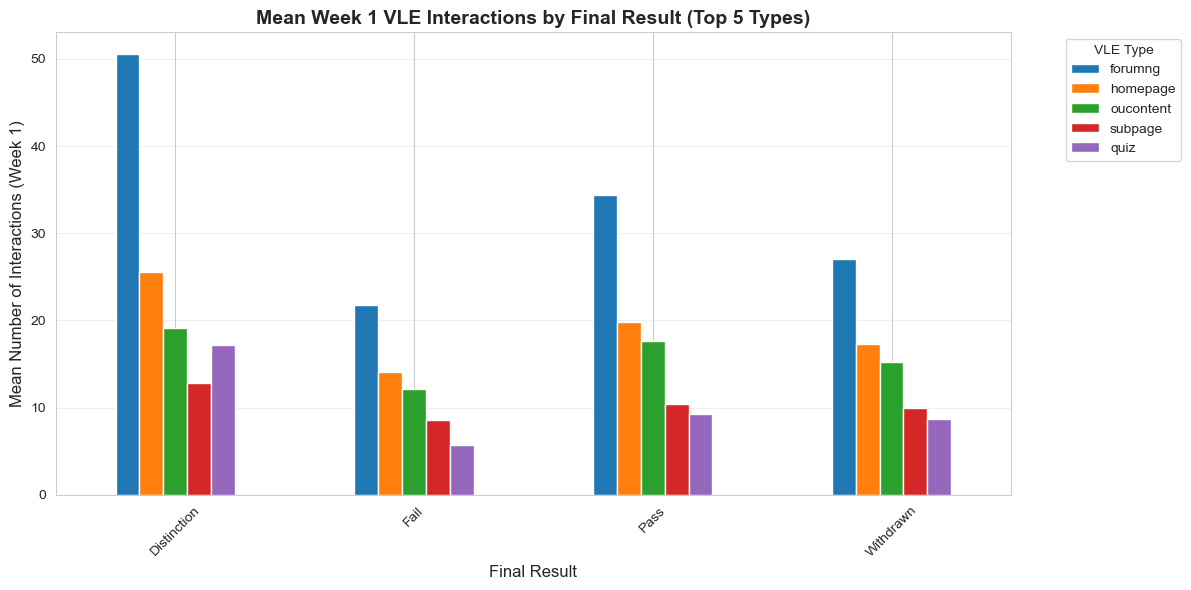

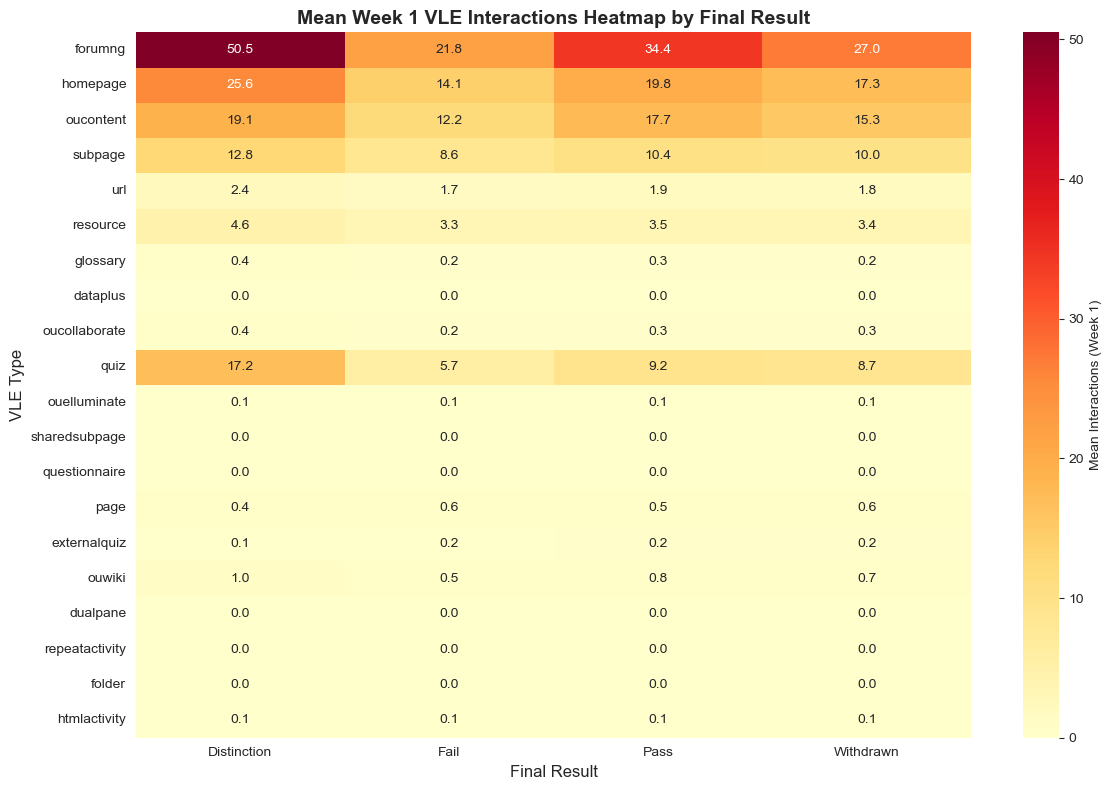


6. CORRELATION BETWEEN WEEK 1 VLE TYPES AND FINAL RESULT

Correlation with final_result (ranked, Week 1 data):
total_vle_interactions_w1     :  0.1606
forumng                       :  0.1498
homepage                      :  0.0911
subpage                       :  0.0903
quiz                          :  0.0879
oucontent                     :  0.0803
url                           :  0.0519
resource                      :  0.0477
ouwiki                        :  0.0473
oucollaborate                 :  0.0459
htmlactivity                  :  0.0275
glossary                      :  0.0232
questionnaire                 :  0.0190
dataplus                      :  0.0087
dualpane                      :  0.0072
externalquiz                  : -0.0007
ouelluminate                  : -0.0011
sharedsubpage                 : -0.0050
page                          : -0.0266
repeatactivity                :     nan
folder                        :     nan


c:\Users\arina\miniforge3\envs\erdos_ds_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\arina\miniforge3\envs\erdos_ds_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


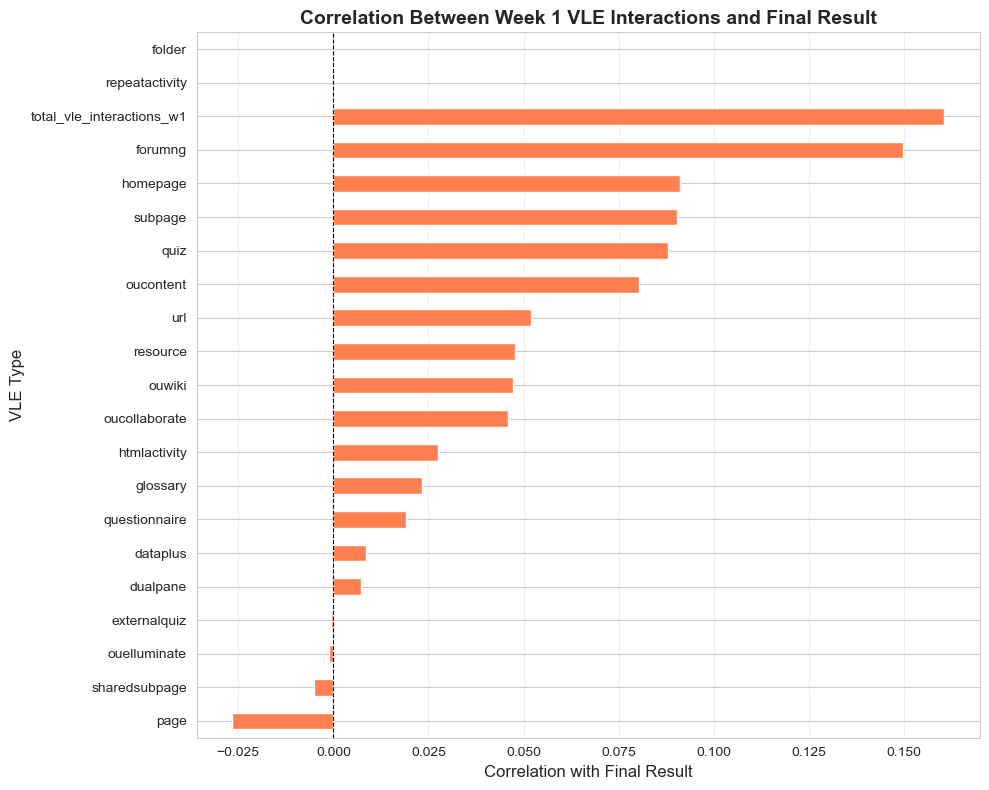

In [10]:
# VISUALIZATIONS

# Bar plot - Mean interactions by final result
fig, ax = plt.subplots(figsize=(12, 6))
mean_by_result_top5 = different_vle_interactions_w1.groupby('final_result')[top_5_vle].mean()
mean_by_result_top5.plot(kind='bar', ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('Mean Number of Interactions (Week 1)', fontsize=12)
ax.set_title('Mean Week 1 VLE Interactions by Final Result (Top 5 Types)', fontsize=14, fontweight='bold')
ax.legend(title='VLE Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap - Mean interactions by final result (all VLE types)
fig, ax = plt.subplots(figsize=(12, 8))
mean_by_result_all = different_vle_interactions_w1.groupby('final_result')[vle_columns].mean()
sns.heatmap(mean_by_result_all.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Interactions (Week 1)'}, ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Mean Week 1 VLE Interactions Heatmap by Final Result', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# CORRELATION ANALYSIS
print("\n" + "="*80)
print("6. CORRELATION BETWEEN WEEK 1 VLE TYPES AND FINAL RESULT")
print("="*80)

# Calculate correlation with final_result (numeric version)
correlations = different_vle_interactions_w1[vle_columns + ['total_vle_interactions_w1']].corrwith(
    different_vle_interactions_w1[result_col]
).sort_values(ascending=False)

print("\nCorrelation with final_result (ranked, Week 1 data):")
for vle, corr in correlations.items():
    print(f"{vle:30s}: {corr:>7.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
correlations.sort_values(ascending=True).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Correlation with Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Correlation Between Week 1 VLE Interactions and Final Result', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Create 3 features to measure diversity of types of interactions with the VLE *per day*

In [11]:
from scipy.stats import entropy

In [12]:
# 1. VLE RICHNESS - Number of different VLE types used
# Higher # = used more types
df['vle_richness'] = (df[vle_columns] > 0).sum(axis=1)

# 2. SHANNON ENTROPY - Overall diversity of interactions 
# Higher # = more diverse
def shannon_entropy(row):
    counts = row[vle_columns].values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

df['diversity_shannon'] = df.apply(shannon_entropy, axis=1)

# 3. DOMINANCE - Proportion of interactions with most-used type
# Higher # = more focused on one type of VLE interaction
def dominance(row):
    counts = row[vle_columns].values.astype(float)
    total = counts.sum()
    if total == 0:
        return 0
    return counts.max() / total

df['dominance'] = df.apply(dominance, axis=1)

In [13]:
# Calculate diversity of interaction metrics per student per code presentation/module *for the entire module*
# Add metric to original dataframe (df)
# And store in new summary table, student_diversity

student_col = 'id_student' 

# Aggregate all interactions per student per course_presentation
student_diversity = df.groupby([student_col, 'code_presentation'])[vle_columns].sum().reset_index()

# Calculate diversity metrics for each student and add to student_diversity
student_diversity['overall_vle_richness'] = (student_diversity[vle_columns] > 0).sum(axis=1)
student_diversity['overall_diversity_shannon'] = student_diversity.apply(shannon_entropy, axis=1)
student_diversity['overall_dominance'] = student_diversity.apply(dominance, axis=1)

# Add final_result to student_diversity dataframe
final_results = df.groupby([student_col, 'code_presentation'])['final_result'].first().reset_index()
student_diversity = student_diversity.merge(final_results, on=[student_col, 'code_presentation'])

# Merge back to original dataframe for student-level metrics on every row
df = df.merge(student_diversity[[student_col, 'code_presentation', 'overall_vle_richness', 
                                  'overall_diversity_shannon', 'overall_dominance']], 
              on=[student_col, 'code_presentation'], 
              how='left')

EDA of the relationship between diversity of interaction metrics and final_result in student_diversity


Average Diversity of Interactions by Final Result:
--------------------------------------------------------------------------------
             overall_vle_richness        overall_diversity_shannon         \
                             mean median                      mean median   
final_result                                                                
Distinction                  9.39    9.0                      2.14   2.19   
Fail                         7.49    7.0                      2.05   2.15   
Pass                         9.14    9.0                      2.16   2.22   
Withdrawn                    7.10    7.0                      2.00   2.13   

             overall_dominance         
                          mean median  
final_result                           
Distinction               0.45   0.42  
Fail                      0.44   0.41  
Pass                      0.43   0.41  
Withdrawn                 0.45   0.41  


C:\Users\arina\AppData\Local\Temp\ipykernel_20576\459958516.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity, x='final_result', y='overall_vle_richness',
C:\Users\arina\AppData\Local\Temp\ipykernel_20576\459958516.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity, x='final_result', y='overall_diversity_shannon',
C:\Users\arina\AppData\Local\Temp\ipykernel_20576\459958516.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity, x='final_result', y='overall_dominance',


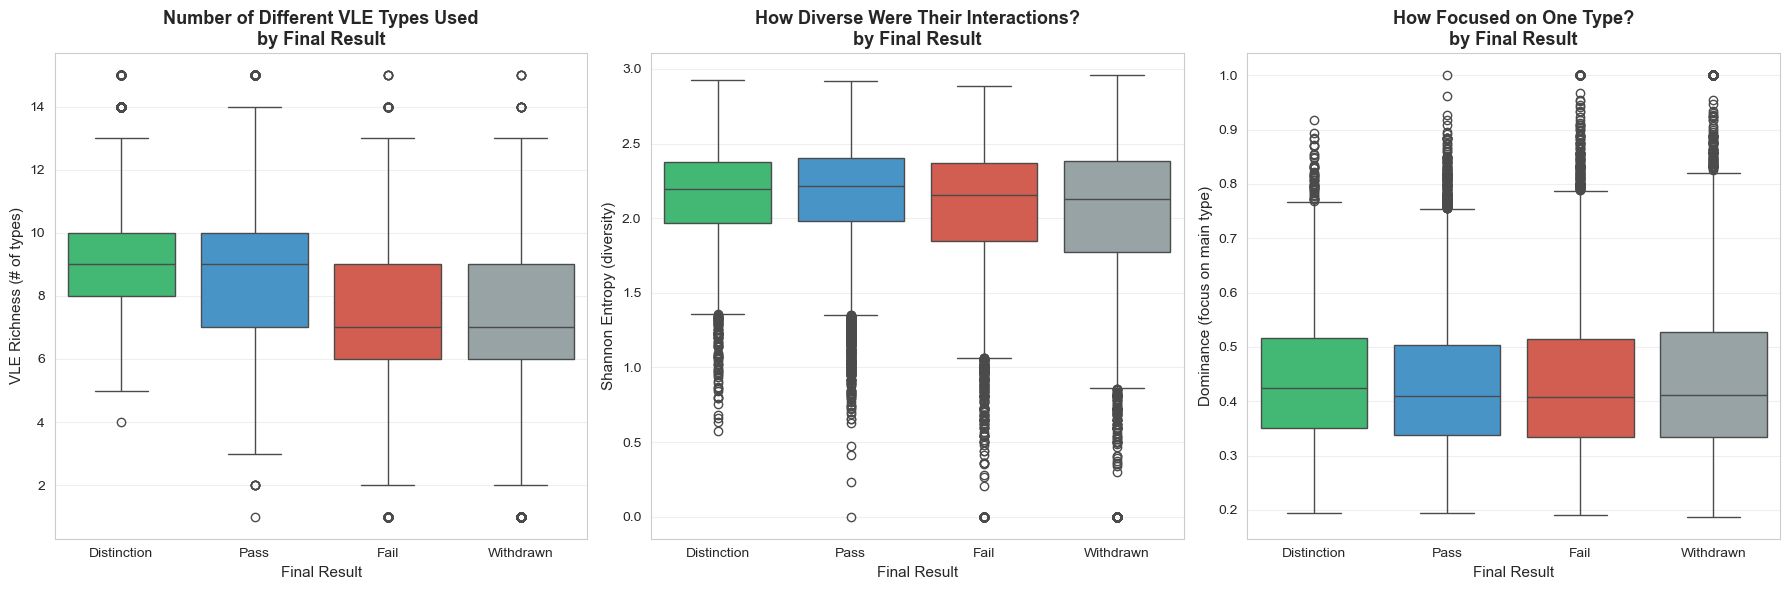

In [14]:
print("\nAverage Diversity of Interactions by Final Result:")
print("-" * 80)
summary = student_diversity.groupby('final_result')[
    ['overall_vle_richness', 'overall_diversity_shannon', 'overall_dominance']
].agg(['mean', 'median']).round(2)
print(summary)

# Box plot visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

# Plot 1: VLE Richness
sns.boxplot(data=student_diversity, x='final_result', y='overall_vle_richness',
            order=result_order, palette=colors, ax=axes[0])
axes[0].set_title('Number of Different VLE Types Used\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Result', fontsize=11)
axes[0].set_ylabel('VLE Richness (# of types)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Shannon Entropy
sns.boxplot(data=student_diversity, x='final_result', y='overall_diversity_shannon',
            order=result_order, palette=colors, ax=axes[1])
axes[1].set_title('How Diverse Were Their Interactions?\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Final Result', fontsize=11)
axes[1].set_ylabel('Shannon Entropy (diversity)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Dominance
sns.boxplot(data=student_diversity, x='final_result', y='overall_dominance',
            order=result_order, palette=colors, ax=axes[2])
axes[2].set_title('How Focused on One Type?\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Final Result', fontsize=11)
axes[2].set_ylabel('Dominance (focus on main type)', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Exploration of statistical significance

metrics = {
    'overall_vle_richness': 'VLE Richness (# of types used)',
    'overall_diversity_shannon': 'Shannon Entropy (diversity score)',
    'overall_dominance': 'Dominance (focus on one type)'
}

for metric_col, metric_name in metrics.items():
    # Get data for each outcome group
    distinction = student_diversity[student_diversity['final_result'] == 'Distinction'][metric_col].dropna()
    pass_group = student_diversity[student_diversity['final_result'] == 'Pass'][metric_col].dropna()
    fail = student_diversity[student_diversity['final_result'] == 'Fail'][metric_col].dropna()
    withdrawn = student_diversity[student_diversity['final_result'] == 'Withdrawn'][metric_col].dropna()
    
    # Statistical test
    f_stat, p_value = stats.f_oneway(distinction, pass_group, fail, withdrawn)
    
    # Calculate effect size (how much does outcome explain the metric?)
    all_data = pd.concat([distinction, pass_group, fail, withdrawn])
    grand_mean = all_data.mean()
    
    ss_between = (len(distinction) * (distinction.mean() - grand_mean)**2 +
                  len(pass_group) * (pass_group.mean() - grand_mean)**2 +
                  len(fail) * (fail.mean() - grand_mean)**2 +
                  len(withdrawn) * (withdrawn.mean() - grand_mean)**2)
    
    ss_total = ((all_data - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    print(f"\n{metric_name}:")
    print(f"  • Statistical test p-value: {p_value:.4f}")
    print(f"  • Strength: {eta_squared*100:.1f}% of variation explained by outcome")



VLE Richness (# of types used):
  • Statistical test p-value: 0.0000
  • Strength: 13.9% of variation explained by outcome

Shannon Entropy (diversity score):
  • Statistical test p-value: 0.0000
  • Strength: 2.5% of variation explained by outcome

Dominance (focus on one type):
  • Statistical test p-value: 0.0000
  • Strength: 0.4% of variation explained by outcome


Create features to measure regularity: how regularly students engage with the VLE

In [16]:
# 1. Overall coefficient of variation for each student over the course of the module

def calculate_regularity_cv(df, student_id_col='id_student', date_col='date'):
    def cv_gaps(x):
        gaps = x.sort_values().diff().dropna()
        if len(gaps) == 0 or gaps.mean() == 0:
            return np.nan
        return gaps.std() / gaps.mean()
    
    cv_scores = df.groupby(student_id_col)[date_col].apply(cv_gaps)
    df['cv_regularity_overall'] = df[student_id_col].map(cv_scores)
    return df

# Lower CV = more regular
# Higher CV = more variable/intermittent
df = calculate_regularity_cv(df)

# Export regularity metric to student_diversity so we have 1 row per student

cv_per_student = df.groupby(['id_student', 'code_presentation'])['cv_regularity_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    cv_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

# 2. Overall standard deviation of gaps for each student over the course of the module

def calculate_regularity_std(df, student_id_col='id_student', date_col='date'):
    regularity = df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std()
    )
    # Add as a new column to the dataframe
    df['std_regularity_overall'] = df[student_id_col].map(regularity)
    return df

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df = calculate_regularity_std(df)

# Extract std_regularity_overall to student_diversity
std_per_student = df.groupby(['id_student', 'code_presentation'])['std_regularity_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    std_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

# 3. Overall average of how many days/week each student logs in over the course of the module

def weekly_consistency(df, student_id_col='id_student', date_col='date', week_col='week'):
    # Count unique days per week
    weekly_days = df.groupby([student_id_col, week_col])[date_col].nunique()
    
    # Calculate std of days per week (lower = more consistent)
    consistency = weekly_days.groupby(student_id_col).std()
    
    # Add as a new column to the dataframe
    df['std_weekly_consistency_overall'] = df[student_id_col].map(consistency)
    
    return df

# Lower values = more consistent weekly activity
# Higher values = more variable weekly activity
df = weekly_consistency(df)

# Extract std_weekly_consistency_overall to student_diversity
weekly_consistency_per_student = df.groupby(['id_student', 'code_presentation'])['std_weekly_consistency_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    weekly_consistency_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

Create features that measure the proportion of student-VLE interactions devoted to content, collaboration, and assessment

In [17]:
from scipy.stats import linregress

In [18]:
# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage', 'glossary', 'subpage', 'folder']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki', 'sharedsubpage']

student_totals = df.groupby(['id_student', 'code_presentation'])[vle_columns].sum()

# Assessment focus
assessment_focus = student_totals[assessment_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
assessment_focus = assessment_focus.fillna(0).rename('assessment_focus_ratio')

# Content focus
content_focus = student_totals[content_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
content_focus = content_focus.fillna(0).rename('content_focus_ratio')

# Collaborative focus
collaborative_focus = student_totals[collaborative_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
collaborative_focus = collaborative_focus.fillna(0).rename('collaborative_focus_ratio')

# Add to df 
df = df.merge(assessment_focus, on=['id_student', 'code_presentation'], how='left')
df = df.merge(content_focus, on=['id_student', 'code_presentation'], how='left')
df = df.merge(collaborative_focus, on=['id_student', 'code_presentation'], how='left')

# Add to student_diversity
student_diversity = student_diversity.merge(
    assessment_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

student_diversity = student_diversity.merge(
    content_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

student_diversity = student_diversity.merge(
    collaborative_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

# Fill any NaN values
student_diversity['assessment_focus_ratio'] = student_diversity['assessment_focus_ratio'].fillna(0)
student_diversity['content_focus_ratio'] = student_diversity['content_focus_ratio'].fillna(0)
student_diversity['collaborative_focus_ratio'] = student_diversity['collaborative_focus_ratio'].fillna(0)


Create week_one dataframe with week 1 data only


In [19]:
week1_data = df[df['week'] == 1].copy()

# Aggregate week 1 total interactions and diversity of interactions data per student - calculate averages
week_one = week1_data.groupby(['id_student', 'code_presentation']).agg({
    'total_vle_interactions': 'mean',  # Average daily interactions in week 1
    'vle_richness': 'mean',            # Average daily richness in week 1
    'diversity_shannon': 'mean',       # Average daily diversity in week 1
    'dominance': 'mean'                # Average daily dominance in week 1
}).reset_index()

# Rename columns to add _w1 suffix
week_one = week_one.rename(columns={
    'total_vle_interactions': 'total_vle_interactions_w1',
    'vle_richness': 'vle_richness_w1',
    'diversity_shannon': 'diversity_shannon_w1',
    'dominance': 'dominance_w1'
})

# Add final_result
final_results = df.groupby(['id_student', 'code_presentation'])['final_result'].first().reset_index()
week_one = week_one.merge(final_results, on=['id_student', 'code_presentation'], how='left')

# Calculate regularity of interaction metrics for week 1 only:
# Filter to week 1 data with actual interactions
week1_active = df[(df['week'] == 1) & (df['total_vle_interactions'] > 0)].copy()

# 1. CV Regularity for Week 1
def cv_gaps_w1(x):
    """Calculate coefficient of variation of login gaps in week 1"""
    gaps = x.sort_values().diff().dropna()
    if len(gaps) == 0 or gaps.mean() == 0:
        return np.nan
    return gaps.std() / gaps.mean()

cv_regularity_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].apply(cv_gaps_w1).reset_index()
cv_regularity_w1.columns = ['id_student', 'code_presentation', 'cv_regularity_w1']

# 2. STD Regularity for Week 1
def std_gaps_w1(x):
    """Calculate standard deviation of login gaps in week 1"""
    gaps = x.sort_values().diff()
    return gaps.std()

std_regularity_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].apply(std_gaps_w1).reset_index()
std_regularity_w1.columns = ['id_student', 'code_presentation', 'std_regularity_w1']

# 3. Active Days in Week 1
active_days_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].nunique().reset_index()
active_days_w1.columns = ['id_student', 'code_presentation', 'active_days_w1']

# Merge all three metrics into week_one table
week_one = week_one.merge(cv_regularity_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(std_regularity_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(active_days_w1, on=['id_student', 'code_presentation'], how='left')

# Fill NaN values with 0 (students with no activity or insufficient data in week 1)
week_one['cv_regularity_w1'] = week_one['cv_regularity_w1'].fillna(0)
week_one['std_regularity_w1'] = week_one['std_regularity_w1'].fillna(0)
week_one['active_days_w1'] = week_one['active_days_w1'].fillna(0)

# Calculate interaction type (assessment vs. content vs. collaborative) metrics for week 1 only:

# Filter to week 1 only and sum interactions per student
week1_vle_totals = df[df['week'] == 1].groupby(['id_student', 'code_presentation'])[vle_columns].sum()

# Calculate Assessment Focus for Week 1
assessment_focus_w1 = week1_vle_totals[assessment_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
assessment_focus_w1 = assessment_focus_w1.fillna(0).reset_index()
assessment_focus_w1.columns = ['id_student', 'code_presentation', 'assessment_focus_ratio_w1']

# Calculate Content Focus for Week 1
content_focus_w1 = week1_vle_totals[content_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
content_focus_w1 = content_focus_w1.fillna(0).reset_index()
content_focus_w1.columns = ['id_student', 'code_presentation', 'content_focus_ratio_w1']

# Calculate Collaborative Focus for Week 1
collaborative_focus_w1 = week1_vle_totals[collaborative_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
collaborative_focus_w1 = collaborative_focus_w1.fillna(0).reset_index()
collaborative_focus_w1.columns = ['id_student', 'code_presentation', 'collaborative_focus_ratio_w1']

# Merge all three focus ratios into week_one table
week_one = week_one.merge(assessment_focus_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(content_focus_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(collaborative_focus_w1, on=['id_student', 'code_presentation'], how='left')

# Fill NaN values with 0 (students with no week 1 activity)
week_one['assessment_focus_ratio_w1'] = week_one['assessment_focus_ratio_w1'].fillna(0)
week_one['content_focus_ratio_w1'] = week_one['content_focus_ratio_w1'].fillna(0)
week_one['collaborative_focus_ratio_w1'] = week_one['collaborative_focus_ratio_w1'].fillna(0)


EDA of relationship between week one engineered features and final_result


1. AVERAGE WEEK 1 METRICS BY FINAL RESULT
--------------------------------------------------------------------------------
final_result                  Distinction    Fail    Pass  Withdrawn
total_vle_interactions_w1          28.652  20.579  24.592     20.680
vle_richness_w1                     3.596   3.390   3.542      3.365
diversity_shannon_w1                1.290   1.254   1.297      1.230
dominance_w1                        0.615   0.616   0.608      0.624
cv_regularity_w1                    0.197   0.164   0.185      0.189
std_regularity_w1                   0.309   0.265   0.299      0.289
active_days_w1                      3.946   2.725   3.402      2.900
assessment_focus_ratio_w1           0.078   0.041   0.052      0.057
content_focus_ratio_w1              0.586   0.702   0.648      0.681
collaborative_focus_ratio_w1        0.335   0.255   0.299      0.259


C:\Users\arina\AppData\Local\Temp\ipykernel_20576\4023641736.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
C:\Users\arina\AppData\Local\Temp\ipykernel_20576\4023641736.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
C:\Users\arina\AppData\Local\Temp\ipykernel_20576\4023641736.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
C:\Users\arina\AppData\Local\Temp\ipykernel_20576\4023641736.py:37: Futur

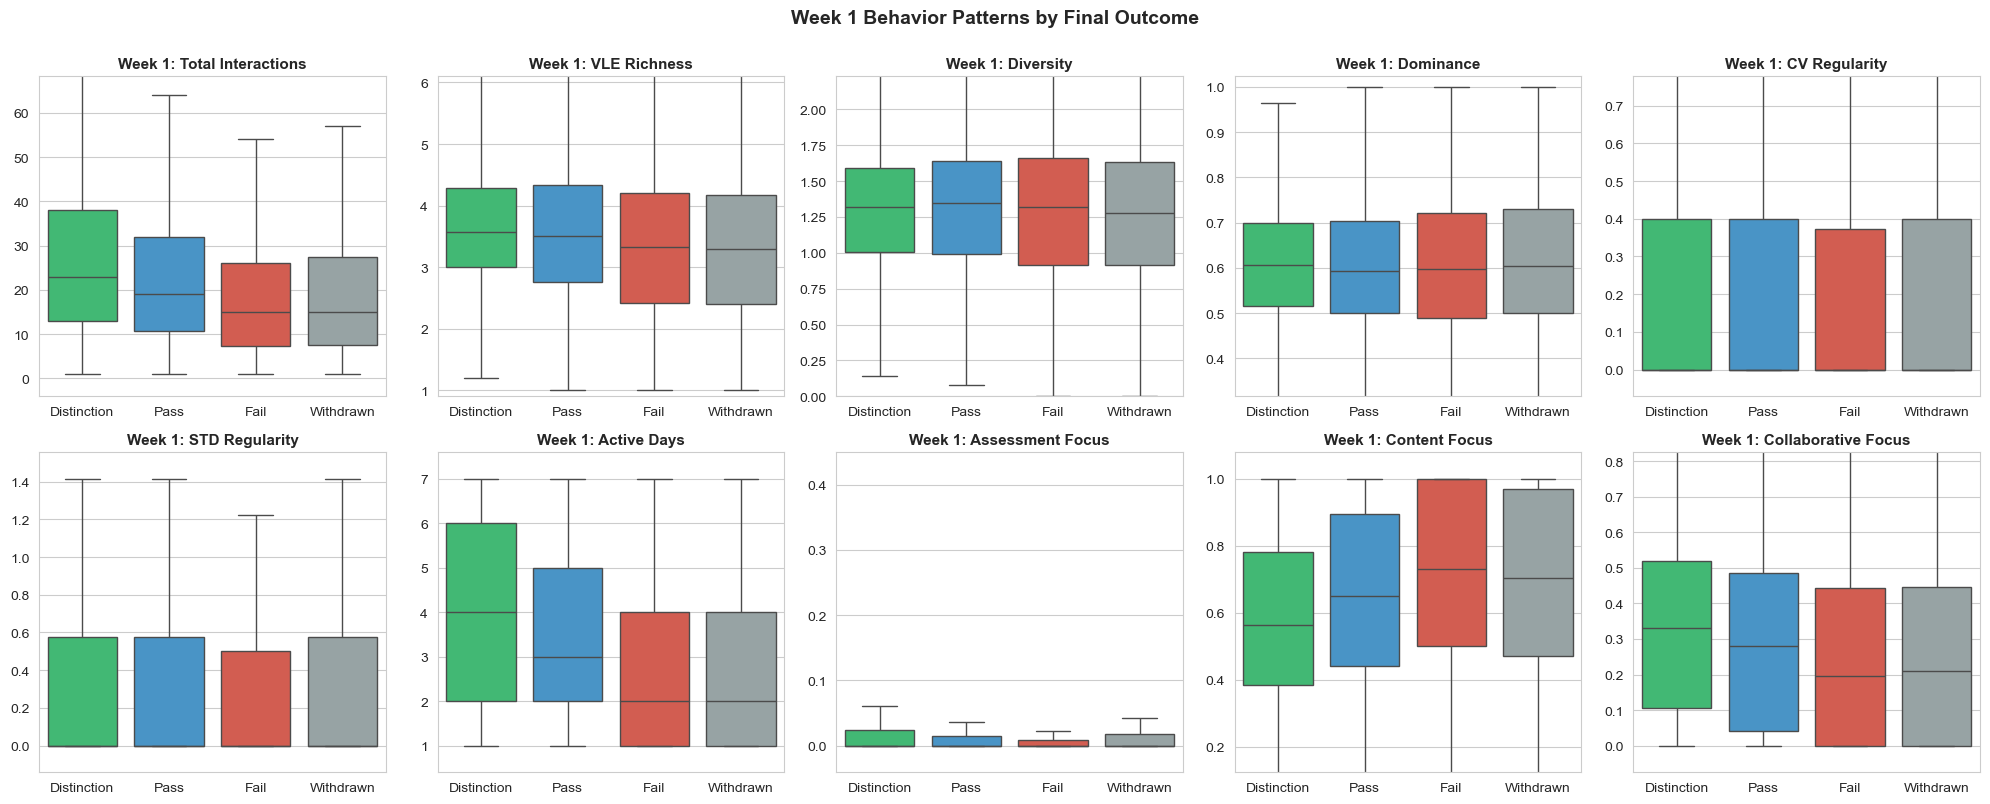


3. STATISTICAL SIGNIFICANCE (Can Week 1 predict outcomes?)
--------------------------------------------------------------------------------
            Feature p-value Sig Variance Explained Predictive?
 Total Interactions  0.0000 ***               1.4%         Yes
       VLE Richness  0.0000 ***               0.5%         Yes
          Diversity  0.0000 ***               0.3%         Yes
          Dominance  0.0000 ***               0.1%         Yes
      CV Regularity  0.0000 ***               0.1%         Yes
     STD Regularity  0.0002 ***               0.1%         Yes
        Active Days  0.0000 ***               4.2%         Yes
   Assessment Focus  0.0000 ***               0.4%         Yes
      Content Focus  0.0000 ***               1.6%         Yes
Collaborative Focus  0.0000 ***               1.1%         Yes


In [20]:
# Define features to analyze
week1_features = [
    'total_vle_interactions_w1', 'vle_richness_w1', 'diversity_shannon_w1', 
    'dominance_w1', 'cv_regularity_w1', 'std_regularity_w1', 'active_days_w1',
    'assessment_focus_ratio_w1', 'content_focus_ratio_w1', 'collaborative_focus_ratio_w1'
]

# 1. Summary: Average values by outcome
print("\n1. AVERAGE WEEK 1 METRICS BY FINAL RESULT")
print("-" * 80)
summary = week_one.groupby('final_result')[week1_features].mean().round(3)
print(summary.T)  # Transpose for easier reading

# 2. Visualizations

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

feature_labels = {
    'total_vle_interactions_w1': 'Total Interactions',
    'vle_richness_w1': 'VLE Richness',
    'diversity_shannon_w1': 'Diversity',
    'dominance_w1': 'Dominance',
    'cv_regularity_w1': 'CV Regularity',
    'std_regularity_w1': 'STD Regularity',
    'active_days_w1': 'Active Days',
    'assessment_focus_ratio_w1': 'Assessment Focus',
    'content_focus_ratio_w1': 'Content Focus',
    'collaborative_focus_ratio_w1': 'Collaborative Focus'
}

for idx, feature in enumerate(week1_features):
    # Create box plot with modified outlier display
    sns.boxplot(data=week_one, x='final_result', y=feature,
                order=result_order, palette=colors, ax=axes[idx],
                showfliers=False)  # Hide extreme outliers
    
    # Set y-axis limits based on 5th and 95th percentiles to focus on main distribution
    q05 = week_one[feature].quantile(0.05)
    q95 = week_one[feature].quantile(0.95)
    margin = (q95 - q05) * 0.1  # Add 10% margin
    axes[idx].set_ylim(q05 - margin, q95 + margin)
    
    axes[idx].set_title(f'Week 1: {feature_labels[feature]}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

plt.suptitle('Week 1 Behavior Patterns by Final Outcome', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# 3. Statistical tests
print("\n3. STATISTICAL SIGNIFICANCE (Can Week 1 predict outcomes?)")
print("-" * 80)

results = []
for feature in week1_features:
    # Get groups
    groups = [week_one[week_one['final_result'] == r][feature].dropna() 
              for r in result_order]
    
    # ANOVA test
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Effect size (eta-squared)
    all_data = pd.concat(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    # Determine significance
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    results.append({
        'Feature': feature_labels[feature],
        'p-value': f'{p_value:.4f}',
        'Sig': sig,
        'Eta_Squared': eta_squared,
        'Variance Explained': f'{eta_squared*100:.1f}%',
        'Predictive?': 'Yes' if p_value < 0.05 else 'No'
    })
results_df = pd.DataFrame(results)
print(results_df[['Feature', 'p-value', 'Sig', 'Variance Explained', 'Predictive?']].to_string(index=False))


1. ETA-SQUARED (η²) - Proportion of variance explained
Range: 0 to 1 (0 = no association, 1 = perfect association)
Interpretation: 0.01=small, 0.06=medium, 0.14=large

                     Feature  Eta_Squared  Variance_Explained_Pct Significance Effect_Size
              active_days_w1     0.042274                4.227384          ***       Small
      content_focus_ratio_w1     0.016161                1.616145          ***       Small
   total_vle_interactions_w1     0.014060                1.406048          ***       Small
collaborative_focus_ratio_w1     0.010936                1.093555          ***       Small
             vle_richness_w1     0.004876                0.487579          ***       Small
   assessment_focus_ratio_w1     0.004430                0.442986          ***       Small
        diversity_shannon_w1     0.002828                0.282841          ***       Small
                dominance_w1     0.001402                0.140226          ***       Small
            

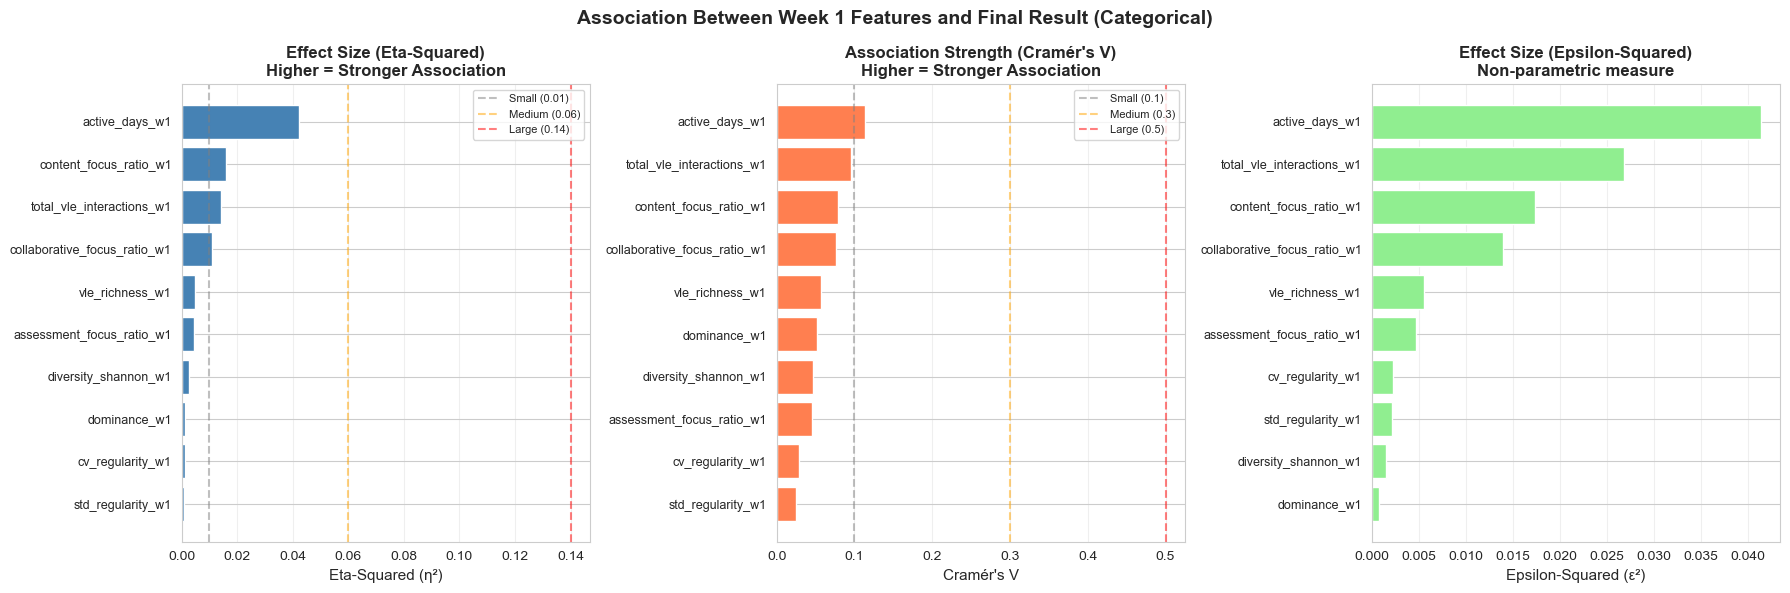

In [21]:
# 1. ETA-SQUARED (Effect Size from ANOVA)
print("\n" + "="*80)
print("1. ETA-SQUARED (η²) - Proportion of variance explained")
print("="*80)
print("Range: 0 to 1 (0 = no association, 1 = perfect association)")
print("Interpretation: 0.01=small, 0.06=medium, 0.14=large\n")

eta_squared_results = []
result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

for feature in week1_features:
    # Get groups
    groups = [week_one[week_one['final_result'] == r][feature].dropna()
              for r in result_order]
    
    # ANOVA F-test
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Calculate eta-squared
    all_data = pd.concat(groups)
    grand_mean = all_data.mean()
    
    # Between-group sum of squares
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    
    # Total sum of squares
    ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
    
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    # Significance
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    eta_squared_results.append({
        'Feature': feature,
        'Eta_Squared': eta_squared,
        'Variance_Explained_Pct': eta_squared * 100,
        'F_statistic': f_stat,
        'p_value': p_value,
        'Significance': sig,
        'Effect_Size': 'Large' if eta_squared >= 0.14 else 'Medium' if eta_squared >= 0.06 else 'Small'
    })

eta_df = pd.DataFrame(eta_squared_results).sort_values('Eta_Squared', ascending=False)
print(eta_df[['Feature', 'Eta_Squared', 'Variance_Explained_Pct', 'Significance', 'Effect_Size']].to_string(index=False))

# 2. CRAMÉR'S V (Association measure for categorical variables)
print("\n" + "="*80)
print("2. CRAMÉR'S V - Association strength (0 to 1)")
print("="*80)
print("Range: 0 to 1 (0 = no association, 1 = perfect association)")
print("Interpretation: 0.1=small, 0.3=medium, 0.5=large\n")

cramers_v_results = []

for feature in week1_features:
    # Discretize continuous feature into bins for Cramér's V
    valid_data = week_one[[feature, 'final_result']].dropna()
    
    try:
        # Create bins (quartiles) without specifying labels
        feature_binned = pd.qcut(valid_data[feature], q=4, duplicates='drop')
        
        # Create contingency table
        contingency = pd.crosstab(feature_binned, valid_data['final_result'])
        
        # Chi-square test
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
        
        # Calculate Cramér's V
        n = contingency.sum().sum()
        min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
        cramers_v = np.sqrt(chi2 / (n * min_dim))
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        
        cramers_v_results.append({
            'Feature': feature,
            'Cramers_V': cramers_v,
            'Chi2_statistic': chi2,
            'p_value': p_value,
            'Significance': sig,
            'Association': 'Large' if cramers_v >= 0.5 else 'Medium' if cramers_v >= 0.3 else 'Small'
        })
    except Exception as e:
        # If binning fails (e.g., too few unique values), use a simpler approach
        print(f"  Warning: Could not calculate Cramér's V for {feature} (using alternative binning)")
        
        # Use simpler binning (median split)
        median_val = valid_data[feature].median()
        feature_binned = (valid_data[feature] > median_val).map({True: 'High', False: 'Low'})
        
        contingency = pd.crosstab(feature_binned, valid_data['final_result'])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
        
        n = contingency.sum().sum()
        min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
        cramers_v = np.sqrt(chi2 / (n * min_dim))
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        
        cramers_v_results.append({
            'Feature': feature,
            'Cramers_V': cramers_v,
            'Chi2_statistic': chi2,
            'p_value': p_value,
            'Significance': sig,
            'Association': 'Large' if cramers_v >= 0.5 else 'Medium' if cramers_v >= 0.3 else 'Small'
        })

cramers_df = pd.DataFrame(cramers_v_results).sort_values('Cramers_V', ascending=False)
print(cramers_df[['Feature', 'Cramers_V', 'Significance', 'Association']].to_string(index=False))

# 3. KRUSKAL-WALLIS H (Non-parametric test)
print("\n" + "="*80)
print("3. KRUSKAL-WALLIS H - Non-parametric group comparison")
print("="*80)

kruskal_results = []

for feature in week1_features:
    groups = [week_one[week_one['final_result'] == r][feature].dropna()
              for r in result_order]
    
    # Kruskal-Wallis test
    h_stat, p_value = stats.kruskal(*groups)
    
    # Effect size (epsilon-squared)
    n = sum(len(g) for g in groups)
    k = len(groups)
    epsilon_sq = (h_stat - k + 1) / (n - k)
    
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    kruskal_results.append({
        'Feature': feature,
        'H_statistic': h_stat,
        'Epsilon_Squared': epsilon_sq,
        'p_value': p_value,
        'Significance': sig
    })

kruskal_df = pd.DataFrame(kruskal_results).sort_values('Epsilon_Squared', ascending=False)
print(kruskal_df[['Feature', 'H_statistic', 'Epsilon_Squared', 'Significance']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Eta-squared
eta_df_sorted = eta_df.sort_values('Eta_Squared', ascending=True)
axes[0].barh(range(len(eta_df_sorted)), eta_df_sorted['Eta_Squared'], color='steelblue')
axes[0].set_yticks(range(len(eta_df_sorted)))
axes[0].set_yticklabels(eta_df_sorted['Feature'], fontsize=9)
axes[0].set_xlabel('Eta-Squared (η²)', fontsize=11)
axes[0].set_title('Effect Size (Eta-Squared)\nHigher = Stronger Association', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=0.01, color='gray', linestyle='--', alpha=0.5, label='Small (0.01)')
axes[0].axvline(x=0.06, color='orange', linestyle='--', alpha=0.5, label='Medium (0.06)')
axes[0].axvline(x=0.14, color='red', linestyle='--', alpha=0.5, label='Large (0.14)')
axes[0].legend(fontsize=8)

# Cramér's V
cramers_df_sorted = cramers_df.sort_values('Cramers_V', ascending=True)
axes[1].barh(range(len(cramers_df_sorted)), cramers_df_sorted['Cramers_V'], color='coral')
axes[1].set_yticks(range(len(cramers_df_sorted)))
axes[1].set_yticklabels(cramers_df_sorted['Feature'], fontsize=9)
axes[1].set_xlabel("Cramér's V", fontsize=11)
axes[1].set_title("Association Strength (Cramér's V)\nHigher = Stronger Association", fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Small (0.1)')
axes[1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Medium (0.3)')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Large (0.5)')
axes[1].legend(fontsize=8)

# Epsilon-squared (from Kruskal-Wallis)
kruskal_df_sorted = kruskal_df.sort_values('Epsilon_Squared', ascending=True)
axes[2].barh(range(len(kruskal_df_sorted)), kruskal_df_sorted['Epsilon_Squared'], color='lightgreen')
axes[2].set_yticks(range(len(kruskal_df_sorted)))
axes[2].set_yticklabels(kruskal_df_sorted['Feature'], fontsize=9)
axes[2].set_xlabel('Epsilon-Squared (ε²)', fontsize=11)
axes[2].set_title('Effect Size (Epsilon-Squared)\nNon-parametric measure', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Association Between Week 1 Features and Final Result (Categorical)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()